<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Input Modeling

Summer Semester 26

Prof. Dr. Gunther Gust <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

# Where we are

<img src="images/simulation_study_steps_input.png" style="width:80%; float:center;" />

Today's focus: **Data Collection** — turning observed reality into the random inputs of our simulation.

# Why input modeling matters

> *"Garbage In, Garbage Out"* — the output of a simulation can never be better than its inputs.

If arrival rates, service times, or demand sizes are wrong, the simulation produces misleading results regardless of how carefully we built the model.

**Input modeling** = the systematic process of choosing distributions and parameters that faithfully represent the real-world randomness driving the system.

# The same model, two distributions

What if we picked the *wrong* distribution? Below, we run the **same** queueing model — same mean interarrival time, same service time — but with two different distributions for arrivals.

/var/folders/s_/tc52sgkj18d_pnr8h48bmz3m0000gn/T/ipykernel_6972/1622954549.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, widths=0.5, patch_artist=True)


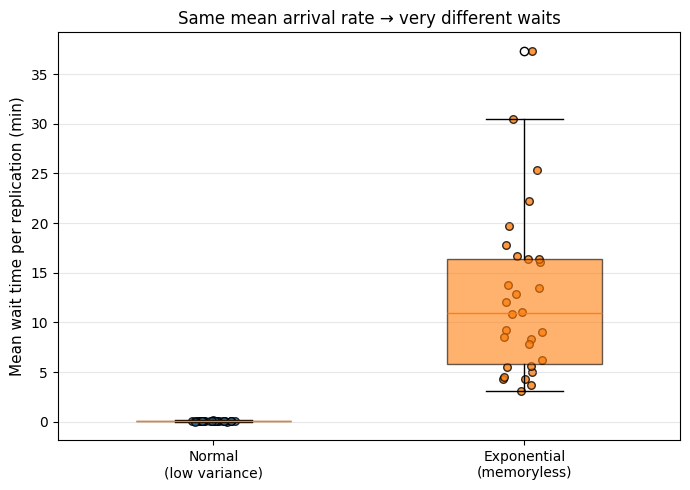

Exponential: mean wait = 12.59 min  (±8.12)
Normal:      mean wait =  0.06 min  (±0.03)

→ Customers wait 195× longer under exponential arrivals!


In [3]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Modeling conventions ---

class EventLogger:
    def __init__(self):
        self.logs = []
    def log(self, **kwargs):
        self.logs.append(kwargs)
    def get_df(self):
        return pd.DataFrame(self.logs)


class Counter:
    """Resource class — a single-server counter."""
    def __init__(self, env, service_time):
        self.env = env
        self.server = simpy.Resource(env, capacity=1)
        self.service_time = service_time

    def serve(self, name):
        yield self.env.timeout(self.service_time)


class Customer:
    """Entity class — one customer queues for service."""
    def __init__(self, env, name, counter, logger):
        self.env = env
        self.name = name
        self.counter = counter
        self.logger = logger

    def run(self):
        arrive = self.env.now
        with self.counter.server.request() as req:
            yield req
            wait = self.env.now - arrive
            yield self.env.process(self.counter.serve(self.name))
            self.logger.log(name=self.name, wait=wait)


def customer_generator(env, counter, logger, arrival_dist):
    """Generator function — produces customers with given interarrival distribution."""
    i = 0
    while True:
        yield env.timeout(arrival_dist())
        c = Customer(env, f"Customer {i}", counter, logger)
        env.process(c.run())
        i += 1


def run_simulation(arrival_dist, seed, sim_time=480):
    """5-step run block — returns mean wait time."""
    random.seed(seed)
    env = simpy.Environment()
    counter = Counter(env, service_time=4.5)
    logger = EventLogger()
    env.process(customer_generator(env, counter, logger, arrival_dist))
    env.run(until=sim_time)
    return logger.get_df()['wait'].mean()


# --- Run experiment: same mean (5 min), two distributions ---
MEAN = 5.0
N_REPS = 30

def exp_arrival():
    return random.expovariate(1 / MEAN)

def norm_arrival():
    return max(0.1, random.normalvariate(MEAN, 0.5))

exp_waits = []
norm_waits = []
for seed in range(N_REPS):
    exp_waits.append(run_simulation(exp_arrival, seed))
    norm_waits.append(run_simulation(norm_arrival, seed))

# --- Plot using d3 colors (D3.js schemeCategory10) ---
D3_BLUE   = '#1f77b4'
D3_ORANGE = '#ff7f0e'

fig, ax = plt.subplots(figsize=(7, 5))
data   = [norm_waits, exp_waits]
labels = ['Normal\n(low variance)', 'Exponential\n(memoryless)']
colors = [D3_BLUE, D3_ORANGE]

bp = ax.boxplot(data, labels=labels, widths=0.5, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
for i, (w, c) in enumerate(zip(data, colors)):
    ax.scatter(np.full(len(w), i+1) + np.random.uniform(-0.07, 0.07, len(w)),
               w, alpha=0.8, color=c, edgecolor='black', s=30)

ax.set_ylabel('Mean wait time per replication (min)', fontsize=11)
ax.set_title('Same mean arrival rate → very different waits', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Exponential: mean wait = {np.mean(exp_waits):5.2f} min  (±{np.std(exp_waits):.2f})")
print(f"Normal:      mean wait = {np.mean(norm_waits):5.2f} min  (±{np.std(norm_waits):.2f})")
print(f"\n→ Customers wait {np.mean(exp_waits)/np.mean(norm_waits):.0f}× longer "
      f"under exponential arrivals!")

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

**Same mean arrival rate, dramatically different waiting times.**

The two simulations use **identical mean inter-arrival times** — yet the customer experience differs by an order of magnitude.

➡️ Choosing the right input distribution is **not optional** — it determines the answer.

# Today's question

> *Given some observed data, how do I turn it into a SimPy input?*

We will solve this end-to-end on **one running case study**, then build up a reference catalog of distributions for future use.

# Modeling choices for input data

Four options — from simplest to most rigorous:

| Option | When to use | Drawback |
|---|---|---|
| **Constant** | No randomness in the system | Ignores variability — often unrealistic |
| **Assume a distribution** | Strong theory or prior research | May not match actual data |
| **Use historical data as-is** | Data available, no fitting needed | Cannot extrapolate beyond observed values |
| **Fit a distribution** ✅ | Data available — **best practice** | Requires effort |



**Why is fitting best?**
- Theoretical distributions have well-known mathematical properties.
- We can generate values *outside* the observed sample range (extrapolation).
- The model stays compact — one distribution + parameters, not a table of raw data.

The **5-step process** on the next slide is how we execute option 4.

# The 5-step process

<br>

| Step | What we do |
|---|---|
| **1. Collect** | Gather data — carefully and systematically |
| **2. Visualize** | Histogram → identify the *shape* |
| **3. Choose family** | Pick a candidate distribution (e.g. Poisson, Normal, ...) |
| **4. Estimate** | Fit parameters to the data |
| **5. Test fit** | Check that the chosen distribution matches the data |

We'll walk through all five steps on one example.

# Case study: car arrivals

A traffic engineer monitors an intersection between **7:00 and 7:05 am** on **100 random workdays** and counts how many vehicles arrive in that 5-minute window.

The goal: build a SimPy simulation of the intersection. We need a distribution for the **number of arrivals per 5-minute window**.

In [4]:
# Load the observed car-arrival data
df_cars = pd.read_csv('data/car_arrivals.csv')
arrivals = df_cars['arrivals'].values

print(f"First 20 observations: {arrivals[:20]}")
print(f"Sample size: {len(arrivals)}")
print(f"Min: {arrivals.min()}, Max: {arrivals.max()}")

First 20 observations: [2 1 3 1 7 4 3 2 9 2 5 1 2 2 2 4 5 2 8 1]
Sample size: 100
Min: 0, Max: 10


# The modeling question

> *What distribution best represents these arrivals?*

We will answer this by walking through all 5 steps.

# Step 1 — Collect Data

<br>

| Status | Step |
|---|---|
| 👉 | **1. Collect** |
|   | 2. Visualize |
|   | 3. Choose family |
|   | 4. Estimate |
|   | 5. Test fit |

# Tips for data collection

- **Plan ahead.** Run a *pre-observation* session before the main collection to spot unusual circumstances.
- **Analyze as you go.** Check data quality continuously, not at the end.
- **Combine homogeneous datasets.** Pool successive time periods only when conditions match.
- **Watch for censoring.** Don't truncate long observations — you'd lose the right tail.
- **Collect *input* data, not *performance* data.** Record interarrival times, not the queue length you want to predict.

# Common mistakes

| # | Mistake | Example | Better practice |
|---|---|---|---|
| 1 | **Outdated data** | Service times measured before a new checkout system was installed — simulation overestimates queue lengths | Refresh data or supplement with expert knowledge |
| 2 | **Multiple causes, one distribution** | Simple orders (2 min) and complex orders (15 min) lumped together → bimodal histogram, no distribution fits | Separate customer types, fit each independently |
| 3 | **Ignoring non-stationarity** | Arrival rates recorded 8 am–8 pm as one dataset — morning rush and quiet afternoon averaged away | Split into time windows, fit each separately |
| 4 | **Ignoring autocorrelation** | A machine running hot produces progressively slower cycles — each observation depends on the previous one | Check scatter diagram; use a time-series model if needed |

# Quick independence check: scatter diagram

Plot each observation against the next one. **Pattern → dependence; cloud → independence.**

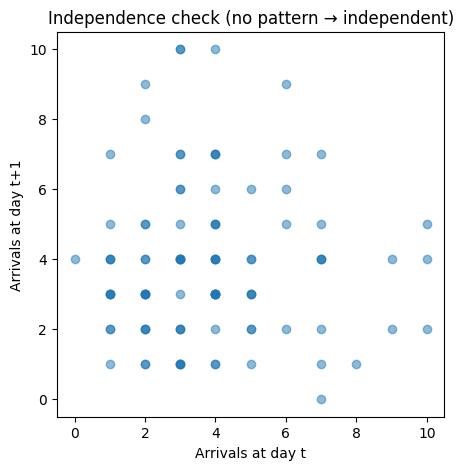

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(arrivals[:-1], arrivals[1:], alpha=0.5)
ax.set_xlabel("Arrivals at day t")
ax.set_ylabel("Arrivals at day t+1")
ax.set_title("Independence check (no pattern → independent)")
plt.show()

# Step 2 — Visualize the data usind a Histogram

<br>

| Status | Step |
|---|---|
| ✅ | 1. Collect |
| 👉 | **2. Visualize** |
|   | 3. Choose family |
|   | 4. Estimate |
|   | 5. Test fit |

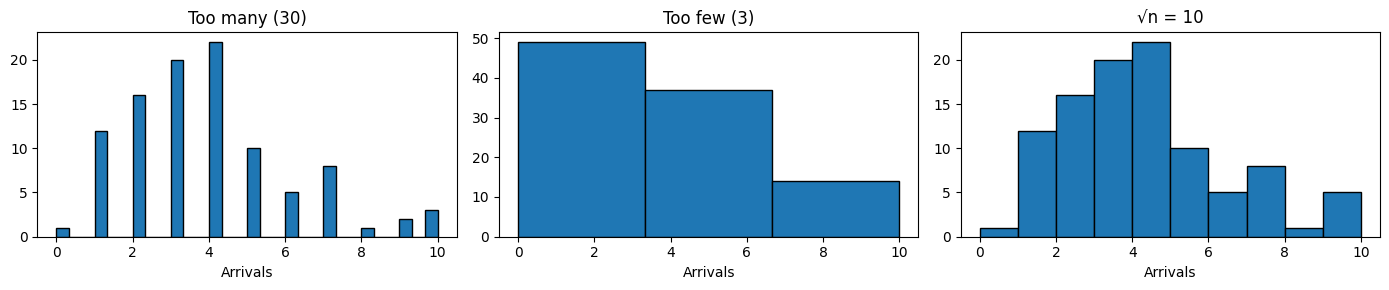

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, bins, title in zip(axes, [30, 3, int(np.sqrt(len(arrivals)))],
                            ['Too many (30)', 'Too few (3)', f'√n = {int(np.sqrt(len(arrivals)))}']):
    ax.hist(arrivals, bins=bins, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Arrivals')
plt.tight_layout(); plt.show()

# How many bins?

The choice of bin width changes the visible shape:

- **Too many bins** → ragged, noisy histogram
- **Too few bins** → loses shape detail
- **Rule of thumb:** number of bins ≈ √n

# Step 3 — Choose a Distribution Family

<br>

| Status | Step |
|---|---|
| ✅ | 1. Collect |
| ✅ | 2. Visualize |
| 👉 | **3. Choose family** |
|   | 4. Estimate |
|   | 5. Test fit |

# Decision tree

The first split is **discrete vs. continuous** — then ask what type of question the variable answers.

```
DISCRETE  (counts, integer outcomes)
├── Yes/no trial(s)
│   ├── single trial               →  Bernoulli
│   └── n fixed trials             →  Binomial
├── Trials until success
│   ├── until 1st success          →  Geometric
│   └── until k-th success         →  Negative Binomial
└── Count of events in an interval →  Poisson


CONTINUOUS  (real-valued measurements)
├── How is the value generated?
│   ├── sum of many small effects     →  Normal
│   └── product of many small effects →  Lognormal
├── Waiting / service time
│   ├── memoryless                    →  Exponential
│   ├── with aging / wear-out         →  Weibull
│   └── multi-stage (k stages)        →  Gamma / Erlang
└── Bounded value
    ├── min / mode / max known        →  Triangular
    ├── flexible shape on [a, b]      →  Beta
    └── range only, otherwise unknown →  Uniform
```


# Distribution Glossary

A reference catalog. For each distribution:

- **Use cases** — when does it arise naturally?
- **Functional form** — the PMF or PDF
  - **PMF** (Probability Mass Function): for discrete distributions, $P(X = k)$ — the probability of each integer outcome
  - **PDF** (Probability Density Function): for continuous distributions, $f(x)$ — the density at each point (probability of an interval = area under the curve)
- **MLE estimator** — Maximum-Likelihood Estimator: the parameter value that makes the observed data most probable
- **Plot of the shape**
- **Python sampling** call

## Discrete distributions

# Bernoulli

**Use cases:** single yes/no trial — coin flip, single customer churns or stays, defective vs. non-defective unit.

**PMF:**
$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

**MLE:** $\hat p = \bar x$ (fraction of successes)

```python
np.random.binomial(n=1, p=0.3)
```

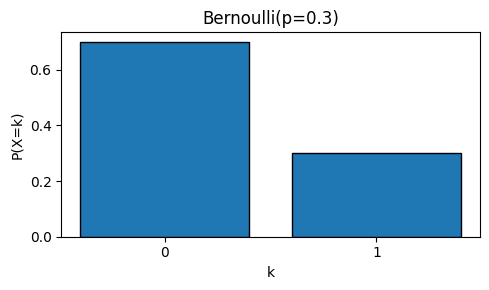

In [7]:
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 3))
p = 0.3
ks = [0, 1]
ax.bar(ks, stats.bernoulli.pmf(ks, p), color='#1f77b4', edgecolor='black')
ax.set_xticks(ks); ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
ax.set_title(f'Bernoulli(p={p})'); plt.tight_layout(); plt.show()

# Binomial

**Use cases:** number of successes in *n* fixed independent trials — defective items in a batch of 50, # of customers (out of 100) who buy.

**PMF:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

**MLE** (n known): $\hat p = \bar x / n$

```python
np.random.binomial(n=20, p=0.3)
```

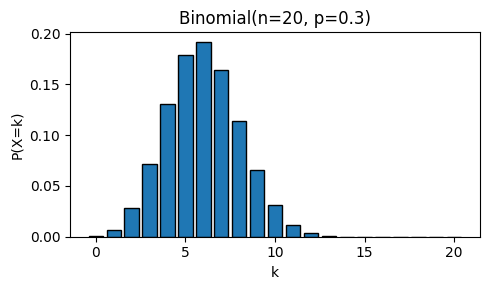

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
n, p = 20, 0.3
ks = np.arange(0, n+1)
ax.bar(ks, stats.binom.pmf(ks, n, p), color='#1f77b4', edgecolor='black')
ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
ax.set_title(f'Binomial(n={n}, p={p})'); plt.tight_layout(); plt.show()

# Geometric

**Use cases:** number of trials until the **first** success — # job applications until first interview, # of attempts until a packet is delivered.

**PMF:**
$$P(X = k) = (1-p)^{k-1} p, \quad k = 1, 2, \ldots$$

**MLE:** $\hat p = 1 / \bar x$

```python
np.random.geometric(p=0.3)
```

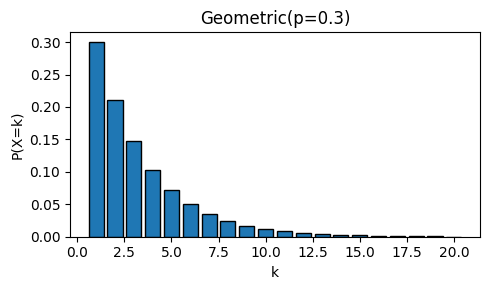

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
p = 0.3
ks = np.arange(1, 21)
ax.bar(ks, stats.geom.pmf(ks, p), color='#1f77b4', edgecolor='black')
ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
ax.set_title(f'Geometric(p={p})'); plt.tight_layout(); plt.show()

# Negative Binomial

**Use cases:** number of trials until the **k-th** success — # of sales calls to land 5 deals; over-dispersed counts (more variance than Poisson).

**PMF:**
$$P(X = n) = \binom{n-1}{r-1} p^r (1-p)^{n-r}, \quad n = r, r+1, \ldots$$

**MLE:** numerical (`scipy.stats.nbinom.fit` not built-in — use method of moments or `statsmodels`).

```python
np.random.negative_binomial(n=5, p=0.3)
```

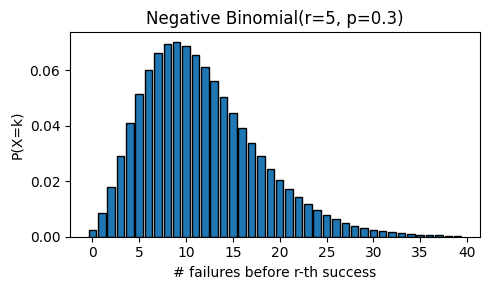

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
r, p = 5, 0.3
ks = np.arange(0, 40)
ax.bar(ks, stats.nbinom.pmf(ks, r, p), color='#1f77b4', edgecolor='black')
ax.set_xlabel('# failures before r-th success'); ax.set_ylabel('P(X=k)')
ax.set_title(f'Negative Binomial(r={r}, p={p})'); plt.tight_layout(); plt.show()

# Poisson

**Use cases:** count of independent events in a fixed interval — calls per hour, cars per 5-min, defects per m².

**PMF:**
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**MLE:** $\hat \lambda = \bar x$

```python
np.random.poisson(lam=3.84)
```

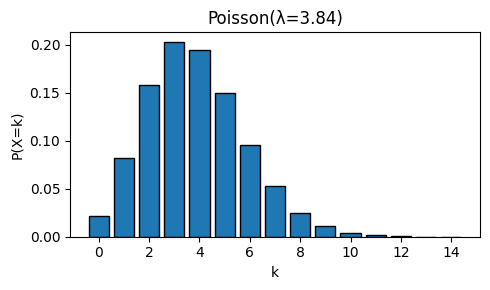

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
lam = 3.84
ks = np.arange(0, 15)
ax.bar(ks, stats.poisson.pmf(ks, lam), color='#1f77b4', edgecolor='black')
ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
ax.set_title(f'Poisson(λ={lam})'); plt.tight_layout(); plt.show()

## Continuous distributions

# Exponential

**Use cases:** memoryless waiting time — interarrival times of random events, time between machine failures (constant failure rate).

**PDF:**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**MLE:** $\hat \lambda = 1 / \bar x$

```python
random.expovariate(lambd=1/mean_time)
```

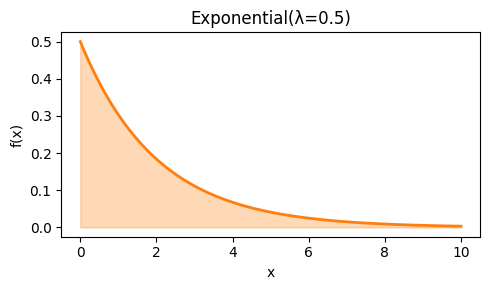

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))
lam = 0.5
x = np.linspace(0, 10, 200)
ax.plot(x, stats.expon.pdf(x, scale=1/lam), color='#ff7f0e', lw=2)
ax.fill_between(x, stats.expon.pdf(x, scale=1/lam), alpha=0.3, color='#ff7f0e')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Exponential(λ={lam})'); plt.tight_layout(); plt.show()

# Normal

**Use cases:** sum of many small independent effects (Central Limit Theorem) — assembly time, measurement errors, sample means.

**PDF:**
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\!\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$$

**MLE:** $\hat\mu = \bar x, \quad \hat\sigma^2 = \frac{1}{n}\sum_i (x_i - \bar x)^2$

```python
random.normalvariate(mu, sigma)
```

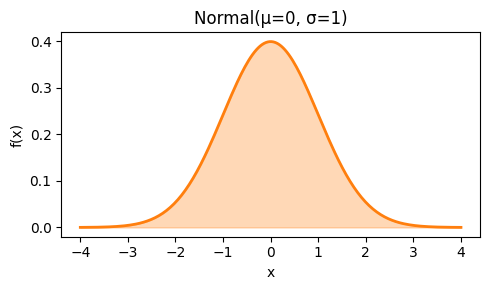

In [13]:
fig, ax = plt.subplots(figsize=(5, 3))
mu, sigma = 0, 1
x = np.linspace(-4, 4, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#ff7f0e', lw=2)
ax.fill_between(x, stats.norm.pdf(x, mu, sigma), alpha=0.3, color='#ff7f0e')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Normal(μ={mu}, σ={sigma})'); plt.tight_layout(); plt.show()

# Lognormal

**Use cases:** quantities arising as a *product* of effects — compounded stock returns, income (multiplicative raises), file sizes, repair durations driven by cascading faults.

**PDF:**
$$f(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\!\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right), \quad x > 0$$

**MLE:** $\hat\mu = \overline{\ln x}, \quad \hat\sigma^2 = \frac{1}{n}\sum_i (\ln x_i - \hat\mu)^2$

```python
random.lognormvariate(mu, sigma)
```

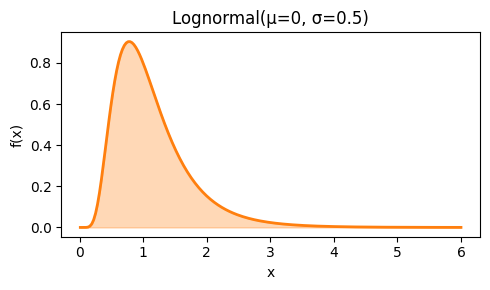

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
mu, sigma = 0, 0.5
x = np.linspace(0.01, 6, 200)
ax.plot(x, stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu)), color='#ff7f0e', lw=2)
ax.fill_between(x, stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu)), alpha=0.3, color='#ff7f0e')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Lognormal(μ={mu}, σ={sigma})'); plt.tight_layout(); plt.show()

# Weibull

**Use cases:** time-to-failure with aging — bearings, lightbulbs, engines. Shape parameter $\beta$ controls the failure mode: $\beta < 1$ early failures, $\beta = 1$ exponential, $\beta > 1$ wear-out.

**PDF:**
$$f(x) = \frac{\beta}{\alpha} \left( \frac{x}{\alpha} \right)^{\beta - 1} \exp\!\left( -\left(\frac{x}{\alpha}\right)^{\beta} \right), \quad x \geq 0$$

**MLE:** numerical — no closed form. Use `scipy.stats.weibull_min.fit(data)`.

```python
random.weibullvariate(alpha, beta)
```

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


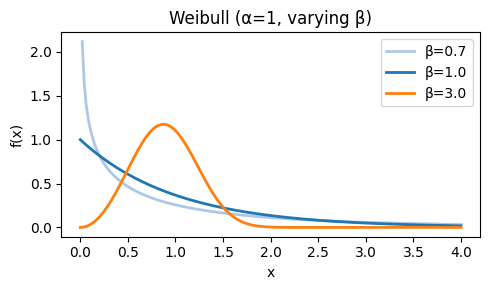

In [15]:
fig, ax = plt.subplots(figsize=(5, 3))
x = np.linspace(0, 4, 200)
for beta, color in [(0.7, '#aec7e8'), (1.0, '#1f77b4'), (3.0, '#ff7f0e')]:
    ax.plot(x, stats.weibull_min.pdf(x, beta, scale=1), lw=2, label=f'β={beta}', color=color)
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Weibull (α=1, varying β)'); plt.tight_layout(); plt.show()

# Gamma / Erlang

**Use cases:** positive continuous quantity arising as the **sum of k exponentials** — total time across $k$ sequential service stages, hospital length-of-stay. Erlang = Gamma with integer shape.

**PDF:**
$$f(x) = \frac{\beta^{\alpha}}{\Gamma(\alpha)} x^{\alpha - 1} e^{-\beta x}, \quad x \geq 0$$

**MLE:** numerical for shape $\alpha$; $\hat\beta = \hat\alpha / \bar x$. Use `scipy.stats.gamma.fit(data)`.

```python
random.gammavariate(alpha, beta)
```

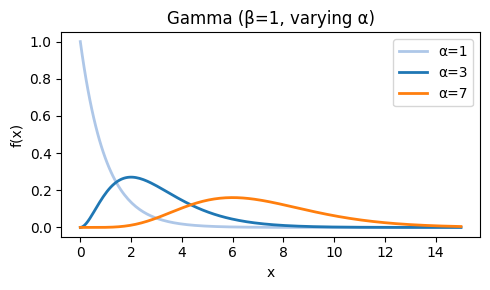

In [16]:
fig, ax = plt.subplots(figsize=(5, 3))
x = np.linspace(0, 15, 200)
for alpha, color in [(1, '#aec7e8'), (3, '#1f77b4'), (7, '#ff7f0e')]:
    ax.plot(x, stats.gamma.pdf(x, alpha, scale=1), lw=2, label=f'α={alpha}', color=color)
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Gamma (β=1, varying α)'); plt.tight_layout(); plt.show()

# Triangular

**Use cases:** when only minimum, most-likely, and maximum are known — expert estimates of task durations, project planning under uncertainty.

**PDF:** (piecewise linear with peak at mode $m$, support $[a, b]$)
$$f(x) = \begin{cases}
\frac{2(x - a)}{(b - a)(m - a)} & a \le x \le m \\
\frac{2(b - x)}{(b - a)(b - m)} & m < x \le b
\end{cases}$$

**MLE:** $\hat a = \min(x), \;\hat b = \max(x), \;\hat m$ via numerical optimization.

```python
random.triangular(low=10, high=30, mode=18)
```

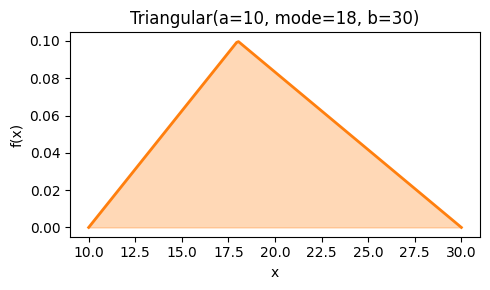

In [17]:
fig, ax = plt.subplots(figsize=(5, 3))
a, m, b = 10, 18, 30
x = np.linspace(a, b, 200)
c = (m - a) / (b - a)
ax.plot(x, stats.triang.pdf(x, c, loc=a, scale=b-a), color='#ff7f0e', lw=2)
ax.fill_between(x, stats.triang.pdf(x, c, loc=a, scale=b-a), alpha=0.3, color='#ff7f0e')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Triangular(a={a}, mode={m}, b={b})'); plt.tight_layout(); plt.show()

# Beta

**Use cases:** quantity bounded in $[0, 1]$ (or rescaled to $[a, b]$) with flexible shape — fraction completed of a project, success probability with prior belief.

**PDF:**
$$f(x) = \frac{x^{\alpha - 1}(1 - x)^{\beta - 1}}{B(\alpha, \beta)}, \quad x \in [0, 1]$$

**MLE:** numerical. Use `scipy.stats.beta.fit(data)`.

```python
np.random.beta(alpha, beta)
```

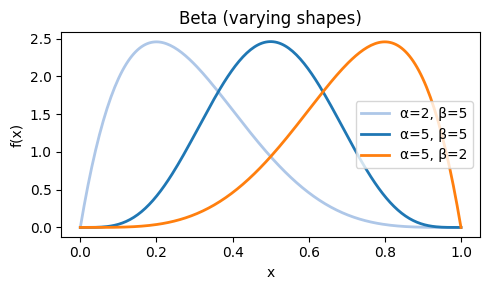

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))
x = np.linspace(0, 1, 200)
for a, b, color in [(2, 5, '#aec7e8'), (5, 5, '#1f77b4'), (5, 2, '#ff7f0e')]:
    ax.plot(x, stats.beta.pdf(x, a, b), lw=2, label=f'α={a}, β={b}', color=color)
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Beta (varying shapes)'); plt.tight_layout(); plt.show()

# Uniform

**Use cases:** last resort when only the range $[a, b]$ is known and no other information is available.

**PDF:**
$$f(x) = \frac{1}{b - a}, \quad x \in [a, b]$$

**MLE:** $\hat a = \min(x), \;\hat b = \max(x)$

```python
random.uniform(a, b)
```

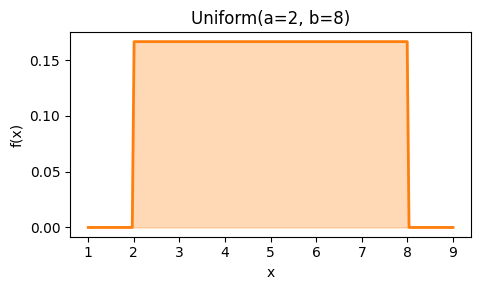

In [19]:
fig, ax = plt.subplots(figsize=(5, 3))
a, b = 2, 8
x = np.linspace(a-1, b+1, 200)
y = stats.uniform.pdf(x, loc=a, scale=b-a)
ax.plot(x, y, color='#ff7f0e', lw=2)
ax.fill_between(x, y, alpha=0.3, color='#ff7f0e')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Uniform(a={a}, b={b})'); plt.tight_layout(); plt.show()

# Empirical (last resort, no theoretical fit)

**Use cases:** when no theoretical family fits and you have enough data — sample directly from the observed values.

- ✅ No distributional assumption
- ❌ Cannot generate values *outside* the observed range
- ❌ Sensitive to data quality and sample size

```python
random.choice(observed_data)   # empirical sampling
```

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

# General procedure for choosing a family

Three converging sources of evidence — then iterate.

**1. Look at the data type**
- Integer counts vs. real-valued measurements?
- Bounded or unbounded?
- Always positive, or can it be negative?

Narrows candidates down.

**2. Consider theory**

The most powerful step — and the most often skipped. Ask what the *theoretical reason* would be for the data to follow a particular distribution. If the underlying mechanism matches a distribution's assumptions, that distribution is likely the right choice — even if the histogram looks noisy.

> **Theory beats fitting.**

**3. Use the histogram as a sanity check**
- Symmetric bell? → Normal
- Right-skewed long tail? → Lognormal, Gamma, Weibull
- Bimodal? → ⚠️ Likely **two populations mixed** — separate and fit each.

**4. Pick one or two candidate families** from the decision tree.

**5. Fit + test.** If the fit fails:
- Re-check independence and stationarity
- Try the second candidate
- Fall back to empirical distribution as a last resort

**Key principle:** theory first, histogram second, automated fitter never alone.

# Step 4 — Estimate Parameters

<br>

| Status | Step |
|---|---|
| ✅ | 1. Collect |
| ✅ | 2. Visualize |
| ✅ | 3. Choose family |
| 👉 | **4. Estimate** |
|   | 5. Test fit |

# Maximum-Likelihood Estimation (MLE) — the idea

> Find the parameter value θ that makes the observed data **most probable**.

For most simulation distributions there is a closed-form MLE. For Poisson:

$$\hat\lambda = \bar{x} \quad \text{(sample mean)}$$

Where does this formula come from? Let's derive it.

# Deriving the MLE for Poisson — Step 1: Likelihood

For a single observation $x_i$ from $\text{Poisson}(\lambda)$:

$$P(X = x_i \mid \lambda) = \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}$$

Assuming the observations $x_1, \ldots, x_n$ are **independent**, the joint probability is the product:

$$L(\lambda) = \prod_{i=1}^{n} \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}$$

This is the **likelihood function** — the probability of seeing the observed data, treated as a function of the unknown parameter $\lambda$.

# Step 2: Log-likelihood

Products are awkward to differentiate. Take the logarithm — the maximum is at the same $\lambda$:

$$\ell(\lambda) = \log L(\lambda) = \sum_{i=1}^{n} \Big[ x_i \log \lambda - \lambda - \log(x_i!) \Big]$$

Simplify by pulling out the sum:

$$\ell(\lambda) = \left( \sum_{i=1}^{n} x_i \right) \log \lambda \; - \; n\lambda \; - \; \sum_{i=1}^{n} \log(x_i!)$$

The last term doesn't depend on $\lambda$ — we can ignore it for maximization.

# Step 3: Maximize

Take the derivative with respect to $\lambda$ and set it to zero:

$$\frac{d\ell}{d\lambda} = \frac{\sum_{i=1}^{n} x_i}{\lambda} - n \;\stackrel{!}{=}\; 0$$

Solve for $\lambda$:

$$\hat\lambda = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{x}$$

✅ The MLE for $\lambda$ is just the **sample mean** of the observations.

(Second-derivative check: $\frac{d^2\ell}{d\lambda^2} = -\frac{\sum x_i}{\lambda^2} < 0$, so it is a maximum.)

# Apply to the case

In [20]:
lambda_hat = arrivals.mean()
print(f"Estimated λ = {lambda_hat:.3f}")

Estimated λ = 3.840


# MLE in Python — `scipy.stats`

For *any* distribution, `scipy.stats.<name>.fit()` returns the MLE:

In [21]:
from scipy import stats

# Step 1: simulate some data we want to model.
# In practice, this would be your observed measurements (e.g. service times).
# Here we draw 200 values from a Normal(μ=10, σ=2) so we know the truth.
sample = np.random.normal(loc=10, scale=2, size=200)

# Step 2: fit the chosen distribution (Normal) to the data via MLE.
# scipy.stats.<dist>.fit(data) returns the MLE estimates of the parameters.
# For the Normal: it returns (mean, std) — the same closed-form MLE we derived.
mu_hat, sigma_hat = stats.norm.fit(sample)

# Step 3: inspect the fitted parameters.
# These should be close to the true values (10, 2) for a sample of size 200.
print(f"Normal fit: μ={mu_hat:.2f}, σ={sigma_hat:.2f}")

Normal fit: μ=10.02, σ=1.97


# Step 5 — Test the Fit

<br>

| Status | Step |
|---|---|
| ✅ | 1. Collect |
| ✅ | 2. Visualize |
| ✅ | 3. Choose family |
| ✅ | 4. Estimate |
| 👉 | **5. Test fit** |

# Visual first: the QQ-plot

A **Quantile-Quantile plot** compares the ordered observed values against the theoretical quantiles of the candidate distribution.

- If the chosen distribution is correct → points fall on a straight line
- Systematic deviation → wrong distribution

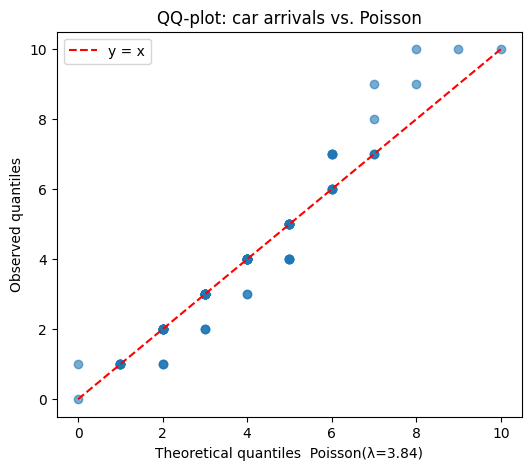

In [22]:
# QQ-plot of car data vs. Poisson
fig, ax = plt.subplots(figsize=(6, 5))
n = len(arrivals)
sorted_data = np.sort(arrivals)
theoretical = stats.poisson.ppf((np.arange(1, n+1) - 0.5) / n, mu=lambda_hat)
ax.scatter(theoretical, sorted_data, alpha=0.6)
ax.plot([0, max(theoretical)], [0, max(theoretical)], 'r--', label='y = x')
ax.set_xlabel(f'Theoretical quantiles  Poisson(λ={lambda_hat:.2f})')
ax.set_ylabel('Observed quantiles')
ax.set_title('QQ-plot: car arrivals vs. Poisson')
ax.legend(); plt.show()

# How is a QQ-plot built?

Given $n$ observations $x_1, \ldots, x_n$ and a fitted candidate distribution with CDF $F$:

**1. Sort the data** in ascending order: $x_{(1)} \leq x_{(2)} \leq \ldots \leq x_{(n)}$.

**2. Assign each ordered value an empirical quantile level**:
$$p_i = \frac{i - 0.5}{n}, \quad i = 1, \ldots, n$$
(So $x_{(i)}$ is treated as the $p_i$-quantile of the data.)

> **Example.** For our car-arrival data, $n = 100$:
> - $p_1 = (1 - 0.5) / 100 = 0.005$ — the smallest observation represents the 0.5% quantile.
> - $p_{50} = (50 - 0.5) / 100 = 0.495$ — the 50th-smallest observation lies near the median.
> - $p_{100} = (100 - 0.5) / 100 = 0.995$ — the largest observation represents the 99.5% quantile.

**3. Compute the theoretical quantile** at the same level:
$$q_i = F^{-1}(p_i)$$
where $F^{-1}$ is the inverse CDF of the candidate distribution (in `scipy`: `dist.ppf(p)`).

**4. Plot** the points $(q_i, x_{(i)})$ for $i = 1, \ldots, n$.

If the candidate distribution fits, $x_{(i)} \approx q_i$ and the points lie on the line $y = x$.

# How to read a QQ-plot

- **Points never fall *exactly* on the line** — there is always sampling noise.
- **Tails are wobbly** — extreme values have high variance. Ignore minor tail deviations.
- **Focus on the middle** — that's where the bulk of the data lies.

# Formal test: Choosing the right test

Two standard goodness-of-fit tests — pick by data type:

| Test | Use for | Idea |
|---|---|---|
| **Chi-square (χ²)** | discrete data (or binned continuous) | Compare observed vs. expected bin counts |
| **Kolmogorov–Smirnov (KS)** | continuous data | Compare empirical and theoretical CDFs |

Our car arrivals are **discrete integer counts** → χ² is the appropriate test.
We will revisit KS later as the continuous-data analogue.

# Chi-square test — concept

**Idea:** divide the data into $k$ bins. For each bin $i$:

- $O_i$ — **observed** count of data points in the bin
- $E_i$ — **expected** count under H₀: $E_i = n \cdot P(X \in \text{bin}_i \mid \hat\theta)$

If H₀ is true, $O_i$ should be close to $E_i$ in every bin. The test statistic measures how far off they are:

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Under H₀: $\chi^2 \sim \chi^2_{k - 1 - p}$ where $p$ = number of estimated parameters (for Poisson, $p = 1$).

> **Rule of thumb:** each bin should have $E_i \geq 5$ — otherwise merge adjacent bins.

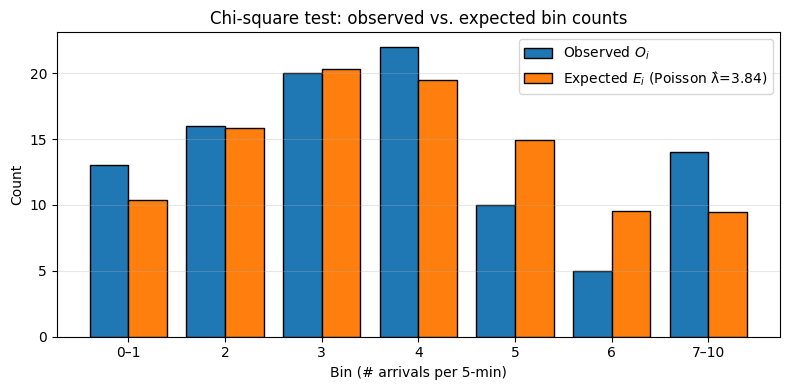

In [23]:
# Chi-square test on the car-arrival data
from scipy.stats import chisquare, poisson

# 1) Build observed and expected counts per integer value
max_k = arrivals.max()
ks_grid = np.arange(0, max_k + 1)
observed = np.array([np.sum(arrivals == k) for k in ks_grid])
expected = len(arrivals) * poisson.pmf(ks_grid, mu=lambda_hat)
# Add the tail (k > max_k) into the last bin so totals match
expected[-1] += len(arrivals) * (1 - poisson.cdf(max_k, mu=lambda_hat))

# 2) Merge bins where E < 5 (combine into the neighboring bin)
merged_O, merged_E, labels = [], [], []
buf_O, buf_E, buf_lbl = 0, 0, []
for k, O, E in zip(ks_grid, observed, expected):
    buf_O += O; buf_E += E; buf_lbl.append(str(k))
    if buf_E >= 5:
        merged_O.append(buf_O); merged_E.append(buf_E)
        labels.append(buf_lbl[0] if len(buf_lbl) == 1 else f'{buf_lbl[0]}–{buf_lbl[-1]}')
        buf_O, buf_E, buf_lbl = 0, 0, []
# Append leftover into last bin
if buf_lbl:
    merged_O[-1] += buf_O; merged_E[-1] += buf_E
    labels[-1] = f'{labels[-1].split("–")[0]}–{buf_lbl[-1]}'

# 3) Visualize observed vs. expected
fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(labels))
w = 0.4
ax.bar(xpos - w/2, merged_O, w, color='#1f77b4', label='Observed $O_i$',
       edgecolor='black')
ax.bar(xpos + w/2, merged_E, w, color='#ff7f0e', label=f'Expected $E_i$ (Poisson λ̂={lambda_hat:.2f})',
       edgecolor='black')
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_xlabel('Bin (# arrivals per 5-min)')
ax.set_ylabel('Count')
ax.set_title('Chi-square test: observed vs. expected bin counts')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [24]:
# 4) Compute the chi-square statistic and p-value
# ddof=1 → df = (k-1) - 1 because we estimated λ from the data
chi2_stat, p_value = chisquare(merged_O, merged_E, ddof=1)
df = len(merged_O) - 1 - 1
print(f"k (number of bins): {len(merged_O)}")
print(f"Degrees of freedom: {df}")
print(f"χ² statistic:       {chi2_stat:.3f}")
print(f"p-value:            {p_value:.3f}")
print(f"\nDecision at α=0.05: "
      f"{'fail to reject H₀ — Poisson fits' if p_value > 0.05 else 'reject H₀'}")

k (number of bins): 7
Degrees of freedom: 5
χ² statistic:       6.976
p-value:            0.222

Decision at α=0.05: fail to reject H₀ — Poisson fits


# Type I and Type II errors — what can go wrong?

We compute $D$ and decide: *is the candidate distribution a good fit, or not?* Two ways to be wrong:

| Decision | H₀ true: the fit really is good | H₁ true: the fit really is bad |
|---|---|---|
| **Don't reject** (accept fit) | ✅ correct | ❌ **Type II error** — we use a wrong distribution |
| **Reject** (refuse fit) | ❌ **Type I error** — false alarm | ✅ correct |

**In plain words:**
- **Type I (α)** — *false alarm*: the distribution actually fits, but we reject it.
- **Type II (β)** — *missed misfit*: the distribution does not fit, but we accept it anyway.

# What is the p-value?

After computing $D$, ask:

> *If the candidate distribution were truly correct, how likely is it to see a gap **at least as large as** the one I observed — purely by chance?*

That probability **is** the p-value.

- **p-value high** (e.g. 0.40) → the observed gap is unsurprising under H₀ → the data is **compatible** with the fit → we don't reject.
- **p-value low** (e.g. 0.01) → such a gap would almost never happen if H₀ were true → the data is **incompatible** with the fit → we reject.

Intuition: the p-value is the *strength of evidence against* the fit. Small p-value = strong evidence.

# What is α?

$\alpha$ is the **threshold** we set in advance. We reject H₀ when the p-value falls below $\alpha$:

$$\text{reject if } \quad p < \alpha$$

- $\alpha = 0.05$ (the conventional choice) means: *"I'm willing to falsely reject a good fit at most 5% of the time."*
- $\alpha$ is, by definition, **the Type I error rate** we accept.

| α | Interpretation | Behavior |
|---|---|---|
| 0.10 | Generous threshold | Rejects easily — more false alarms |
| 0.05 | Standard | The default in most fields |
| 0.01 | Strict | Rarely rejects — but misses real misfits |

# The trade-off: α vs. β

Picture the two possible "worlds" — H₀ (good fit) and H₁ (bad fit) — as two distributions of the test statistic. The **red line** is our rejection threshold.

- **Blue area** to the right of the line = $\alpha$ (Type I — we reject although H₀ is true)
- **Orange area** to the left of the line = $\beta$ (Type II — we accept although H₁ is true)

Move the red line **right** → blue area shrinks, but orange area grows. Move it **left** → vice versa. **You cannot reduce both at once by moving the line.**

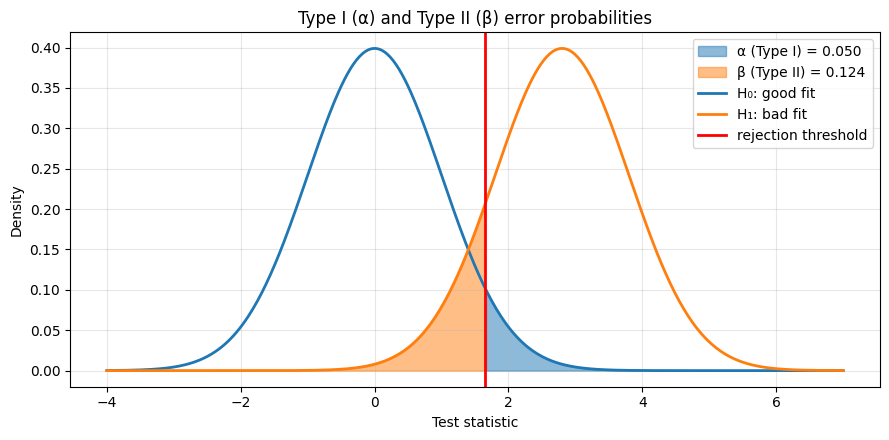

In [25]:
# Illustration: Type I and Type II error probabilities
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(9, 4.5))

# Two hypotheses: H0 ~ N(0, 1), H1 ~ N(2.8, 1)
mu0, mu1, sigma = 0, 2.8, 1.0
x = np.linspace(-4, 7, 500)
pdf0 = norm.pdf(x, mu0, sigma)
pdf1 = norm.pdf(x, mu1, sigma)

# Critical value chosen so α ≈ 0.05 (one-sided)
crit = norm.ppf(0.95, mu0, sigma)

# Type I error (α): blue area right of crit under H0
ax.fill_between(x, 0, pdf0, where=(x >= crit), color='#1f77b4', alpha=0.5,
                label=f'α (Type I) = {1 - norm.cdf(crit, mu0, sigma):.3f}')
# Type II error (β): green area left of crit under H1
ax.fill_between(x, 0, pdf1, where=(x <= crit), color='#ff7f0e', alpha=0.5,
                label=f'β (Type II) = {norm.cdf(crit, mu1, sigma):.3f}')

ax.plot(x, pdf0, color='#1f77b4', lw=2, label='H₀: good fit')
ax.plot(x, pdf1, color='#ff7f0e', lw=2, label='H₁: bad fit')
ax.axvline(crit, color='red', lw=2, label='rejection threshold')

ax.set_xlabel('Test statistic')
ax.set_ylabel('Density')
ax.set_title('Type I (α) and Type II (β) error probabilities')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# How to read the trade-off plot

Each element in the figure has a specific meaning — read them in this order:

**1. The two curves (the "two worlds") — sampling distributions of the test statistic**

Each curve shows the **distribution of the test statistic** (e.g. $D$) — i.e. *the values you'd see if you repeated the experiment many times under that hypothesis*.

- **Blue curve** — the distribution of the test statistic *if H₀ were actually true* (the candidate fits). Most replications give a small $D$ (just sampling noise), but occasionally a larger $D$ appears by chance.
- **Orange curve** — the distribution of the test statistic *if H₁ were actually true* (the candidate is wrong). Now the gap is driven by a real misfit, so $D$ tends to be larger — the curve sits to the right.

They overlap because the test statistic is random — even a wrong fit can occasionally produce a small $D$, and a correct fit can occasionally produce a large $D$.

> ℹ️ **In practice you compute only *one* value of $D$ from your data** — a single point on the x-axis. The curves describe what *would* happen across hypothetical replications. The red threshold is calibrated using the blue curve (we assume H₀ when setting α).

**2. The red vertical line — your decision rule**
- To the **right** of the line → reject H₀ (declare a misfit).
- To the **left** of the line → don't reject H₀ (accept the fit).
- The position of the line is set by your chosen α.

**3. The blue shaded area = α (Type I)**
- This is the **probability of being right of the red line *if H₀ is true*** — i.e. the chance of a false alarm.
- Reading: *"if the candidate really fits, how often will I wrongly reject it?"*

**4. The orange shaded area = β (Type II)**
- This is the **probability of being left of the red line *if H₁ is true*** — i.e. the chance of a missed misfit.
- Reading: *"if the candidate is actually wrong, how often will I fail to detect it?"*

**5. Mentally slide the red line**
- Move it **right** → blue area shrinks (less α), orange area grows (more β).
- Move it **left** → vice versa.
- The two errors trade off — but the curves themselves don't move.

# The free lunch: larger sample size

A bigger sample **tightens both distributions** (the standard error of the test statistic shrinks like $1/\sqrt{n}$). The two bells become narrower and overlap less.

→ For the **same** rejection threshold, both $\alpha$ and $\beta$ shrink simultaneously.

**More data is the only way to reduce both error types at once.**

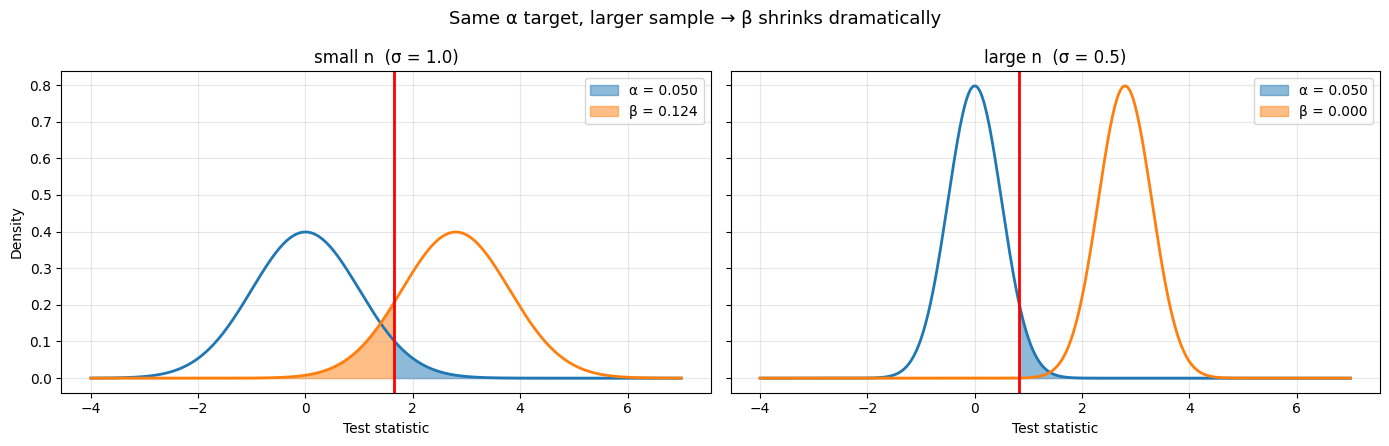

In [26]:
# Illustration: same setup but with larger sample size (smaller σ)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

mu0, mu1 = 0, 2.8
crit_target_alpha = 0.05

for ax, (sigma, n_label) in zip(axes, [(1.0, 'small n'), (0.5, 'large n')]):
    x = np.linspace(-4, 7, 500)
    pdf0 = norm.pdf(x, mu0, sigma)
    pdf1 = norm.pdf(x, mu1, sigma)
    crit = norm.ppf(1 - crit_target_alpha, mu0, sigma)

    alpha_val = 1 - norm.cdf(crit, mu0, sigma)
    beta_val  = norm.cdf(crit, mu1, sigma)

    ax.fill_between(x, 0, pdf0, where=(x >= crit), color='#1f77b4', alpha=0.5,
                    label=f'α = {alpha_val:.3f}')
    ax.fill_between(x, 0, pdf1, where=(x <= crit), color='#ff7f0e', alpha=0.5,
                    label=f'β = {beta_val:.3f}')
    ax.plot(x, pdf0, color='#1f77b4', lw=2)
    ax.plot(x, pdf1, color='#ff7f0e', lw=2)
    ax.axvline(crit, color='red', lw=2)

    ax.set_xlabel('Test statistic')
    ax.set_title(f'{n_label}  (σ = {sigma})')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle('Same α target, larger sample → β shrinks dramatically', fontsize=13)
plt.tight_layout(); plt.show()

# How to read the sample-size plot

Two panels — same two-worlds setup, but the **sample size differs**:

**Left panel — small n** (σ = 1.0)
- The bells are wide, so they overlap heavily.
- Large orange area → high β (we miss a lot of real misfits).
- The test has **low power**.

**Right panel — large n** (σ = 0.5)
- A bigger sample shrinks the standard error of the test statistic by $1/\sqrt{n}$ → both bells become **narrower**.
- The two worlds are now **clearly separated**.
- The red line is repositioned to keep α = 0.05 unchanged.
- The orange area collapses → β shrinks dramatically.

**Key takeaway:**
- We did *not* change α (still 0.05 in both panels).
- We did *not* move the red line in a tricky way.
- We just **collected more data** — and β fell from large to nearly zero.

➡️ **The only "free lunch" in hypothesis testing is collecting more observations.**

# Verdict

<br>

| Step | Result |
|---|---|
| 1. Collect | ✅ 100 observations of arrivals/5-min |
| 2. Visualize | ✅ Discrete, right-skewed — Poisson-shaped |
| 3. Choose family | ✅ Poisson |
| 4. Estimate | ✅ λ̂ = 3.84 |
| 5. Test fit | ✅ QQ-plot linear, χ² p > 0.05 |

**Conclusion:** model arrivals in SimPy as `np.random.poisson(lam=3.84)`.

# Aside — the Kolmogorov–Smirnov (KS) test (for continuous data)

For our discrete car-arrival case the χ² test is the right tool. For *continuous* candidate distributions (Normal, Exponential, Weibull, ...) the natural alternative is the **Kolmogorov–Smirnov test**.

The KS statistic is the **maximum vertical gap** between the empirical CDF and the theoretical CDF (cumulative distribution function):

$$D = \max_x \,| F_n(x) - F(x) |$$

- Small $D$ → distributions agree (fail to reject H₀)
- Large $D$ → distributions differ (reject H₀)

We compare $D$ to a critical value, or equivalently look at the p-value (analogous logic to χ²).

# Visualizing the KS statistic

Conceptually, plot two curves on the same axes:

- **Empirical CDF** $F_n(x)$ — a step function that jumps by $1/n$ at each observation
- **Theoretical CDF** $F(x)$ — the CDF of the fitted candidate distribution

The KS statistic $D$ is the largest vertical gap between them. If the candidate fits, the two curves overlap closely; if it does not, they diverge — and the largest gap reveals where the misfit is strongest.

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

# What if there is no data?

Sometimes you must build a model before any data has been collected. Sources of information:

- **Engineering specifications** — manufacturer ratings, production standards
- **Expert opinion** — optimistic / most-likely / pessimistic estimates
- **Physical limits** — known min and max bounds

Common distribution choices: **Uniform, Triangular, Beta**.

# Triangular from expert estimates

A salesperson estimates a task time:

- minimum: 10 min
- most likely: 18 min
- maximum: 30 min

→ `random.triangular(10, 30, 18)`

Better than `Uniform(10, 30)` because it concentrates probability near the mode.

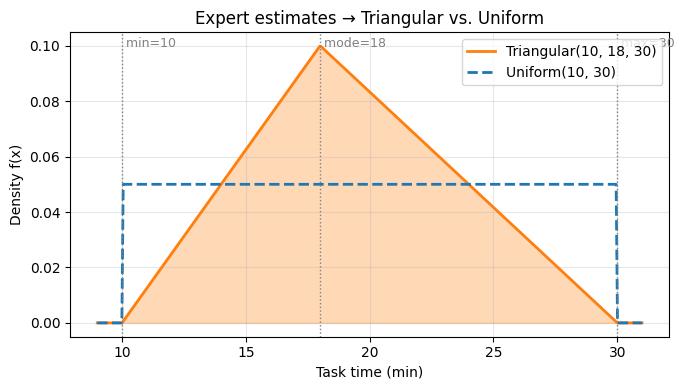

In [27]:
# Plot Triangular vs. Uniform with the same support
LOW, MODE, HIGH = 10, 18, 30
x = np.linspace(LOW - 1, HIGH + 1, 400)
c = (MODE - LOW) / (HIGH - LOW)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, stats.triang.pdf(x, c, loc=LOW, scale=HIGH - LOW),
        color='#ff7f0e', lw=2, label='Triangular(10, 18, 30)')
ax.fill_between(x, stats.triang.pdf(x, c, loc=LOW, scale=HIGH - LOW),
                alpha=0.3, color='#ff7f0e')
ax.plot(x, stats.uniform.pdf(x, loc=LOW, scale=HIGH - LOW),
        color='#1f77b4', lw=2, ls='--', label='Uniform(10, 30)')
# Mark the elicited points
for v, lbl in [(LOW, 'min'), (MODE, 'mode'), (HIGH, 'max')]:
    ax.axvline(v, color='gray', lw=1, ls=':')
    ax.text(v, ax.get_ylim()[1] * 0.95, f' {lbl}={v}', fontsize=9, color='gray')
ax.set_xlabel('Task time (min)')
ax.set_ylabel('Density f(x)')
ax.set_title('Expert estimates → Triangular vs. Uniform')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Expert opinion → CDF

A salesperson states beliefs about annual sales of product XYZ:

| Statement | Cumulative probability |
|---|---|
| At least 1000 units | F(1000) = 0.00 |
| 90% chance > 2000 | F(2000) = 0.10 |
| 25% chance > 2500 | F(2500) = 0.75 |
| 1% chance > 4500 | F(4500) = 0.99 |
| At most 5000 units | F(5000) = 1.00 |

Plot these points → connect them by **linear interpolation** to obtain a piecewise-linear CDF → sample by inverse CDF.


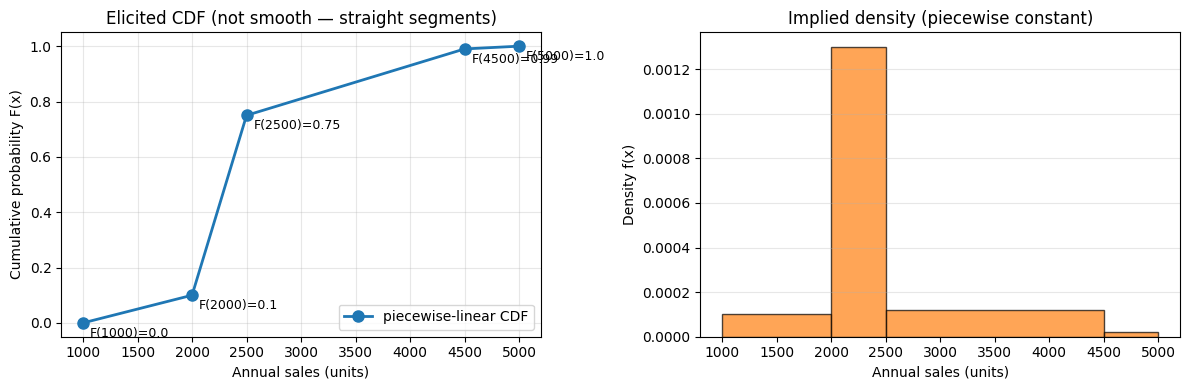

In [28]:
# Salesperson CDF — piecewise-linear interpolation between elicited points
quantile_points = [(1000, 0.00), (2000, 0.10), (2500, 0.75),
                   (4500, 0.99), (5000, 1.00)]
xs = np.array([p[0] for p in quantile_points])
fs = np.array([p[1] for p in quantile_points])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: piecewise-linear CDF
ax = axes[0]
ax.plot(xs, fs, color='#1f77b4', lw=2, marker='o', markersize=8,
        label='piecewise-linear CDF')
for x, f in quantile_points:
    ax.annotate(f'F({x})={f}', xy=(x, f), xytext=(5, -10),
                textcoords='offset points', fontsize=9)
ax.set_xlabel('Annual sales (units)')
ax.set_ylabel('Cumulative probability F(x)')
ax.set_title('Elicited CDF (not smooth — straight segments)')
ax.grid(alpha=0.3); ax.legend(loc='lower right')

# Right: implied (piecewise-constant) density
ax = axes[1]
densities = (fs[1:] - fs[:-1]) / (xs[1:] - xs[:-1])
ax.bar(xs[:-1], densities, width=xs[1:] - xs[:-1], align='edge',
       color='#ff7f0e', edgecolor='black', alpha=0.7)
ax.set_xlabel('Annual sales (units)')
ax.set_ylabel('Density f(x)')
ax.set_title('Implied density (piecewise constant)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# Goodness-of-fit caveats

Two important asymmetries:

- **Small sample** → tests have low power. *Almost any* candidate will pass. ⚠️ Don't over-interpret a "good fit".
- **Very large sample** → tests are extremely sensitive. *Almost any* candidate gets rejected, even if practically adequate.

➡️ **Combine visual checks (QQ-plot) with statistical tests** — and use domain knowledge.

# Beware automated fitting software

Tools that report "best-fit distribution" often:

- Pick a distribution that overfits noise
- Ignore practical interpretability (e.g. fitting Beta when Exponential would do)
- Hide assumptions (independence, stationarity)

➡️ Use them as a **starting point**, not a final answer.

# Stationarity and dependence

Before fitting an iid distribution, check that:

1. **No trend over time** (stationarity). If there is a trend → detrend or model time-dependence.
2. **No autocorrelation.** If consecutive observations correlate → the iid assumption is wrong.

Both are easily missed by automated fitters.

# Homogeneity check via QQ-plot

Want to combine two datasets (e.g. Monday morning + Tuesday morning) into one distribution?

→ Plot the **ordered values of both** against each other.

- Roughly straight line → same distribution, safe to combine.
- Curved or split → different distributions, keep separate.

# Recap — the 5-step process

<br>

| Step | Tool |
|---|---|
| **1. Collect** | Plan ahead, check independence, avoid common mistakes |
| **2. Visualize** | Histogram with √n bins |
| **3. Choose family** | Decision tree → candidate distribution |
| **4. Estimate** | `scipy.stats.<dist>.fit(data)` (or closed-form MLE) |
| **5. Test fit** | QQ-plot first, then KS test |

# Advanced techniques 

When real data is more complex than iid samples from a single distribution:

- **Multivariate input models** — when several inputs are correlated (e.g. demand *and* lead time, or arrival rate *and* service intensity). Joint distributions or copulas.
- **Time-series input models** — when observations form a time-dependent sequence (trend, seasonality, autocorrelation). ARIMA, Hawkes processes, non-homogeneous Poisson processes.
- **Batch arrivals** — when entities arrive in groups rather than individually (e.g. tour buses, ship cargo). Compound Poisson and similar.

These are beyond the scope of this lecture but are covered in:
- Banks et al. (2013), *Discrete-Event System Simulation*, Chapter 9
- Law (2014), *Simulation Modeling and Analysis*, Chapter 6

# Next session

- **Exercise:** apply the 5-step process to real datasets — discrete (χ² test) and continuous (KS test) — and feed the fitted distribution into a SimPy simulation.
- **Next lecture:** **sampling** — how SimPy and `numpy` actually generate random numbers from the distributions we just fitted (inverse-CDF sampling, rejection sampling, pseudo-random number generators).

<img src="images/d3.png" style="width:60%; float:center;" />